<a href="https://colab.research.google.com/github/harishmuh/Computer_Vision_study/blob/main/Object_segmentation_YOLOv8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Object Segmentation with YOLOv8**




## **Context**

Object segmentation is a computer vision task that involves identifying and delineating objects within an image at a pixel level. Unlike object detection, which simply draws bounding boxes around objects, segmentation assigns a class label to each pixel belonging to an object, creating a precise mask for each instance.

**Benefits of Object Segmentation**

1.  **Pixel-Level Accuracy**: Provides highly detailed information about object shapes and boundaries, enabling more precise analysis than bounding box detection.
2.  **Scene Understanding**: Contributes to a deeper understanding of image content by separating individual objects from their background and other objects.
3.  **Applications**: Essential for tasks requiring fine-grained object manipulation or analysis, such as medical image analysis, autonomous driving (for precise lane and obstacle detection), robotics, and augmented reality.

**Limitations of Object Segmentation**

1.  **Computational Cost**: Generally more computationally intensive and slower than object detection due to the need for pixel-level prediction.
2.  **Data Requirements**: Often requires larger and more meticulously annotated datasets (pixel-level masks) for training, which can be time-consuming and expensive to create.
3.  **Complexity**: Models can be more complex to design and train, requiring specialized architectures and training techniques.

**Initial setup**

In [3]:
# Installing additional library
#!pip install ultralytics #Remove the ('#') to install

In [2]:
# Importing libraries
from ultralytics import YOLO
import matplotlib.pyplot as plt
import cv2
from PIL import Image
import urllib.request
import numpy as np
from google.colab.patches import cv2_imshow

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


**YOLOv8 Model preparation**

In [4]:
# Preparing YOLOv8

# Downloading YOLOv8 starter files
model = YOLO('yolov8m-seg.pt')

## **YOLO object segmentation on JPG file**

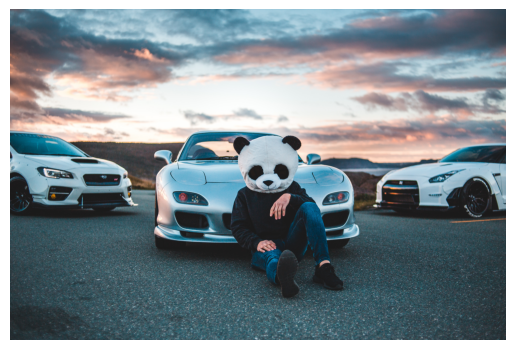

In [14]:
# Attaching the input image

# Image link
url = 'https://github.com/harishmuh/Deep-Learning_study/blob/main/data/DeepCV/person-car.jpg?raw=true'

# Download and open the image
with urllib.request.urlopen(url) as f:
    input_img = Image.open(f)

# Convert PIL Image to NumPy array for OpenCV compatibility
input_img = np.array(input_img)

# Displaying the original image
plt.axis('off')
plt.imshow(input_img, cmap='gray')
plt.show()

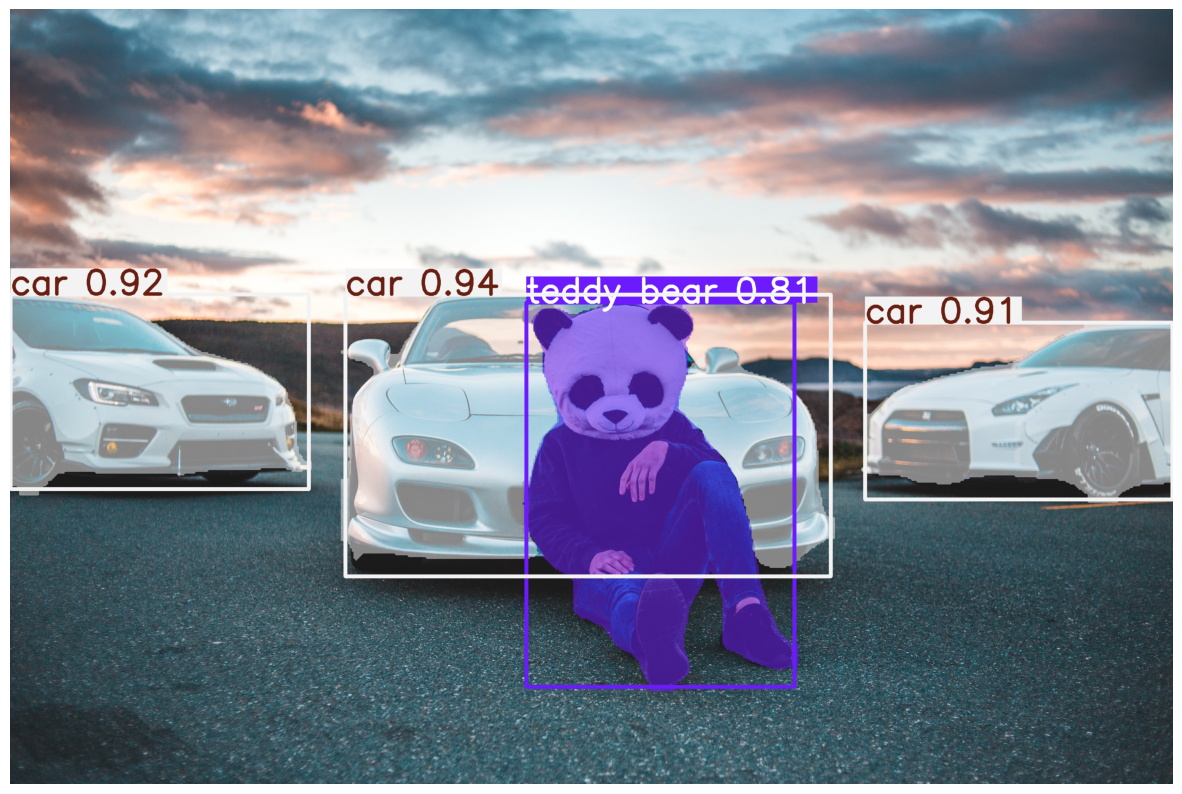

In [15]:
# Conduting object detection (YOLOv8) in input image
prediction = model.predict(input_img, agnostic_nms=True)
result = prediction[0]

# plot detection result on the input image
img_detect = result.plot(line_width=15)

# Displaying the detected image
plt.figure(figsize=(15,15))
plt.axis('off')
plt.imshow(img_detect)
plt.show()

## **YOLO object segmentation on PNG file**

PNG file contains 4 channels, so we need to convert the file format from RGBA to RGB that contains 3 channels before doing object segmentation.

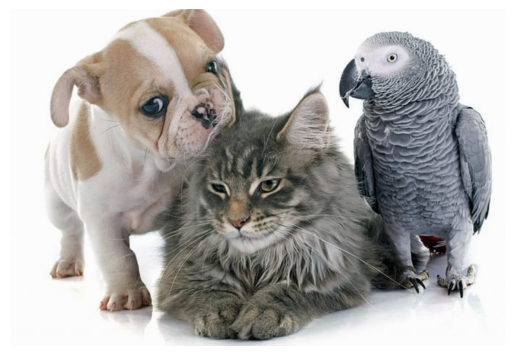

In [16]:
# Attaching the input image

# Image link
url_png = 'https://github.com/harishmuh/Computer_Vision_study/blob/main/data/images/dog%20cat%20bird.PNG?raw=true'

# Download and open the image
with urllib.request.urlopen(url_png) as f:
    input_img_png = Image.open(f)

# Convert PIL Image to NumPy array for OpenCV compatibility
input_img_png = np.array(input_img_png)

# Displaying the original image
plt.axis('off')
plt.imshow(input_img_png, cmap='gray')
plt.show()

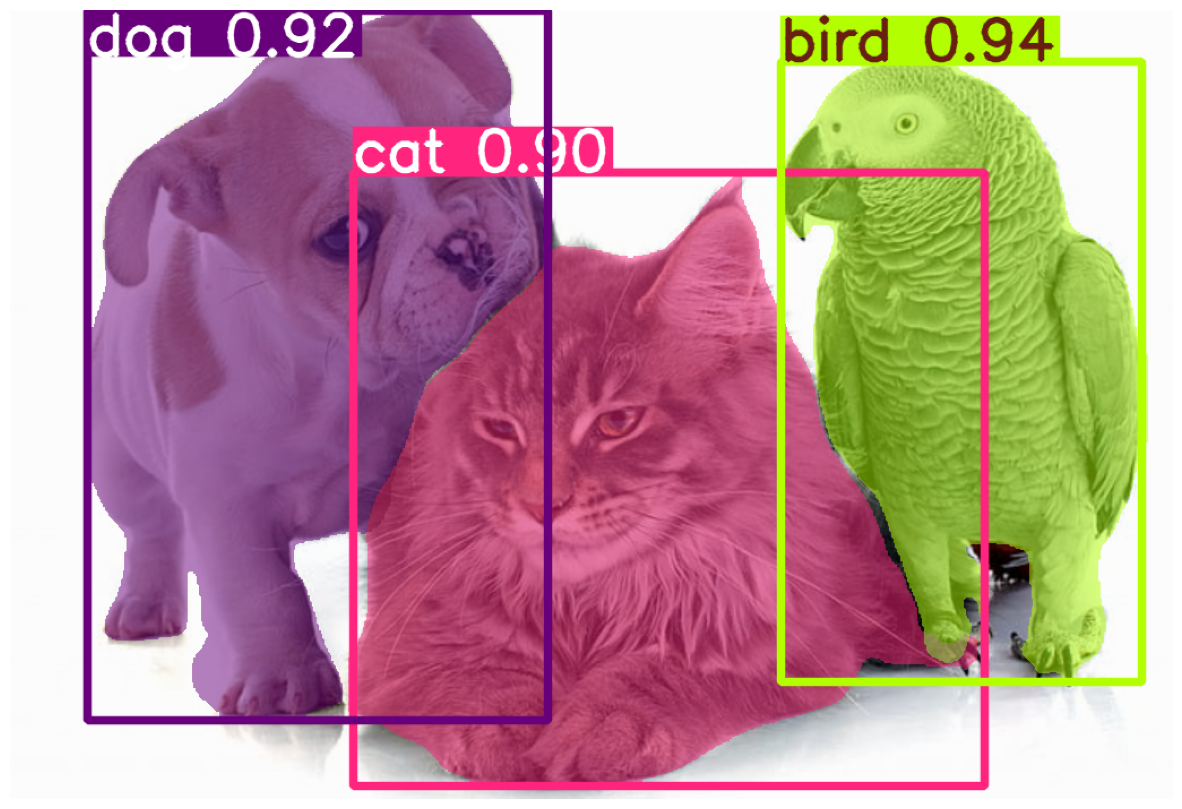

In [17]:
# Conduting object segmentation (YOLOv8) in input image

# Convert input_img_png from RGBA to RGB if it has 4 channels
if input_img_png.shape[-1] == 4:
    input_img_png = cv2.cvtColor(input_img_png, cv2.COLOR_RGBA2RGB)

prediction = model.predict(input_img_png, agnostic_nms=True)
result = prediction[0]

# plot detection result on the input image
img_detect = result.plot(line_width=5)


# Displaying the detected image
plt.figure(figsize=(15,15))
plt.axis('off')
plt.imshow(img_detect)
plt.show()

## **Conclusion**

This notebook demonstrates object segmentation using YOLOv8, showcasing its ability to detect and segment objects in both JPG and PNG image formats. We've seen how to prepare the model, handle different image channels (e.g., converting RGBA to RGB for PNGs), and visualize the segmentation results. YOLOv8 proves to be a powerful tool for pixel-level object identification in various computer vision applications.